## Packages

In [1]:
import matplotlib_inline.backend_inline as backend_inline
import IPython.display as disp
# Make set_matplotlib_formats available where Scanpy expects it
disp.set_matplotlib_formats = backend_inline.set_matplotlib_formats

import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
#import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_header()

C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1023403583.py:1: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
matplotlib-inline,0.1.7
numpy,2.1.1
pandas,2.3.0
scanpy,1.11.3
matplotlib,3.10.6
scipy,1.15.3
seaborn,0.13.2
scirpy,0.12.2
Component,Info
Python,"3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]"


In [3]:
pd.reset_option("^display")

## Directory variables

In [4]:
import glob
import os
from pathlib import Path

sample_directory = './GEX_VDJ/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

In [5]:
plt.rcParams['figure.figsize']=(6,6) #rescale figures
### you can set a default figure directory here for saving output
sc.settings.figdir = "./analysis_output/figures_scanpy/"
## Figure directory for matplotlib figures/axes
save_figure_sc = "./analysis_output/figures_scanpy/"
#Use
#plt.savefig(save_figure + 'image.pdf')
save_figure_ir = "./analysis_output/figures_scirpy/"
#csv directory
read_csv = './analysis_output/saved_tables/'
save_csv = r'./analysis_output/saved_tables/'

## Load data

In [6]:
# define sample metadata. Usually read from a file.
samples = {
    "mult_neg_st": {"group": "mouse_31_40_stim_multimer_negative"},
    "mult_neg_us": {"group": "mouse_31_40_unstim_multimer_negative"},
    "mult_pos_st": {"group": "mouse_31_40_stim_multimer_positive"},
    "mult_pos_us": {"group": "mouse_31_40_unstim_multimer_positive"},
    "1_CD44hi_st": {"group": "mouse_1_10_stim"},
    "1_CD44hi_us": {"group": "mouse_1_10_unstim"},
    "2_CD44hi_st": {"group": "mouse_11_20_stim"},
    "2_CD44hi_us": {"group": "mouse_11_20_unstim"},
    "3_CD44hi_st": {"group": "mouse_21_30_stim"},
    "3_CD44hi_us": {"group": "mouse_21_30_unstim"},

    "1_dp_mult": {"group": "mouse_1_20_dp_mult_unstim"},
    "2_dp_mult": {"group": "mouse_21_40_dp_mult_unstim"},
    "3_dp_mult": {"group": "mouse_41_60_dp_mult_unstim"},
    "4_dp_mult": {"group": "mouse_61_80_dp_mult_unstim"},

    "1_cd107a": {"experiment": "1_cd107a", "group": "exp1"},
    "2_cd107a": {"experiment": "2_cd107a", "group": "exp1"},
    "3_cd107a": {"experiment": "3_cd107a", "group": "exp2"},
    "4_cd107a": {"experiment": "4_cd107a", "group": "exp2"},
    "5_cd107a": {"experiment": "5_cd107a", "group": "exp3"},
    "6_cd107a": {"experiment": "6_cd107a", "group": "exp3"},
    "7_cd107a": {"experiment": "7_cd107a", "group": "exp4"},
    "8_cd107a": {"experiment": "8_cd107a", "group": "exp4"},

}

In [7]:
# Create a list of AnnData objects (one for each sample)
adatas = []
for sample, sample_meta in samples.items():
    adata = sc.read(f'{adata_directory}/{sample}_hash_solo.h5ad')
    adatas.append(adata)
    
    


In [8]:
for adata in adatas:
    print(adata.obs.experiment[0])

mult_neg_st
mult_neg_us
mult_pos_st
mult_pos_us
1_CD44hi_st
1_CD44hi_us
2_CD44hi_st
2_CD44hi_us
3_CD44hi_st
3_CD44hi_us
1_dp_mult
2_dp_mult
3_dp_mult
4_dp_mult
1_cd107a
2_cd107a
3_cd107a
4_cd107a
5_cd107a
6_cd107a
7_cd107a
8_cd107a


C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1461785740.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(adata.obs.experiment[0])


## Concatenation

In [9]:
import anndata

In [10]:
key_list = ['mult_neg_st', 'mult_neg_us',
            'mult_pos_st', 'mult_pos_us',
            '1_CD44hi_st', '1_CD44hi_us',
            '2_CD44hi_st', '2_CD44hi_us',
            '3_CD44hi_st', '3_CD44hi_us',
            '1_dp_mult', '2_dp_mult',
            '3_dp_mult', '4_dp_mult',
            '1_cd107a', '2_cd107a',
            '3_cd107a', '4_cd107a',
            '5_cd107a', '6_cd107a',
            '7_cd107a', '8_cd107a',
           ]

In [11]:
adata = anndata.concat(adatas, keys = key_list, index_unique='-')

In [12]:
import gc
del adatas
gc.collect()

53

In [13]:
adata.raw = adata.copy()

In [14]:
adata.layers['counts'] = adata.X.copy()

### Cell cycle scoring

C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\3454730614.py:7: FutureWarning: The specified parameters ('s_genes', 'g2m_genes') are no longer positional. Please specify them like `s_genes=0         Mcm5
1         Pcna
2         Tyms
3         Fen1
4         Mcm2
5         Mcm4
6         Rrm1
7          Ung
8        Gins2
9         Mcm6
10       Cdca7
11         Dtl
12       Prim1
13       Uhrf1
14      Mlf1ip
15       Hells
16        Rfc2
17        Rpa2
18        Nasp
19    Rad51ap1
20        Gmnn
21       Wdr76
22        Slbp
23       Ccne2
24        Ubr7
25       Pold3
26        Msh2
27       Atad2
28       Rad51
29        Rrm2
30       Cdc45
31        Cdc6
32        Exo1
33       Tipin
34       Dscc1
35         Blm
36    Casp8ap2
37        Usp1
38       Clspn
39       Pola1
40      Chaf1b
41       Brip1
42        E2f8
43       Hmgb2
44        Cdk1
45      Nusap1
Name: genes, dtype: object`
  sc.tl.score_genes_cell_cycle(adata, s_genes.genes, g2m_genes.genes)
genes are not in va

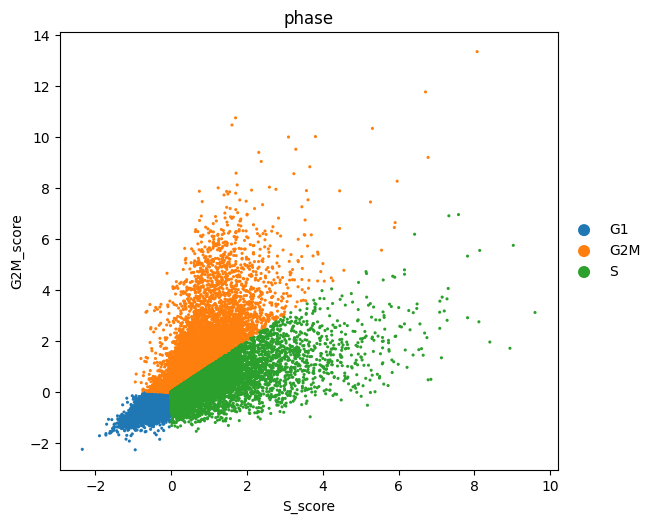

In [15]:
cc_genes=pd.read_csv(analysis_info+'regev_lab_cell_cycle_genes.txt', header=None, names=['genes'])
cc_genes['genes']=cc_genes['genes'].str.lower().str.capitalize() #mouse gene annotation
s_genes=cc_genes[:46]
g2m_genes=cc_genes[47:]
s_genes.columns=['genes']
g2m_genes.columns=['genes']
sc.tl.score_genes_cell_cycle(adata, s_genes.genes, g2m_genes.genes)
sc.pl.scatter(adata, x='S_score', y='G2M_score', color='phase', size=20)

### Doublet identification

In [16]:
sc.pp.scrublet(adata, batch_key='experiment')

In [17]:
adata.obs['predicted_doublet'].value_counts()

predicted_doublet
False    226993
True         30
Name: count, dtype: int64

Hashtag barcoding (see HashSolo) seems to reliably resolve doublet issues in the data

### Normalize gene expression and save to layers

Select count matrix for different normalization methods, keep raw count of all genes, normalize only on HVGs and save to layers

Select HVGs

In [18]:
sc.experimental.pp.highly_variable_genes(
        adata, flavor="pearson_residuals", n_top_genes=5000, chunksize=400
    )

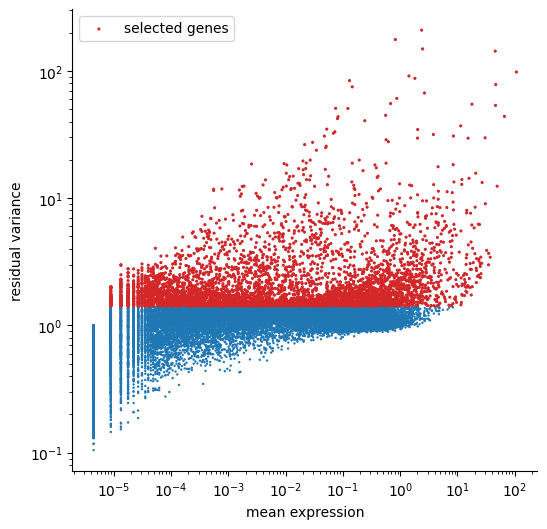

In [19]:
fig, ax = plt.subplots(figsize=(6,6))

hvgs = adata.var["highly_variable"]

ax.scatter(
    adata.var["means"], adata.var["residual_variances"], s=3, edgecolor="none")

ax.scatter(
    adata.var["means"][hvgs],
    adata.var["residual_variances"][hvgs],
    c="tab:red",
    label="selected genes",
    s=5,
    edgecolor="none",
)
ax.set_xscale("log")
ax.set_xlabel("mean expression")
ax.set_yscale("log")
ax.set_ylabel("residual variance")
#ax.set_title(adata.uns["name"])

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
                       
plt.legend()

Optional: Analytic pearson residuals - only run on HVGs, but full data

In [20]:
selected_hvgs = adata.var["highly_variable"].tolist()

Optional: check pearson entries

Shifted Logarithm

In [21]:
#old target sum during HVG only selection
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()

In [22]:
adata.layers

Layers with keys: counts, log1p_norm

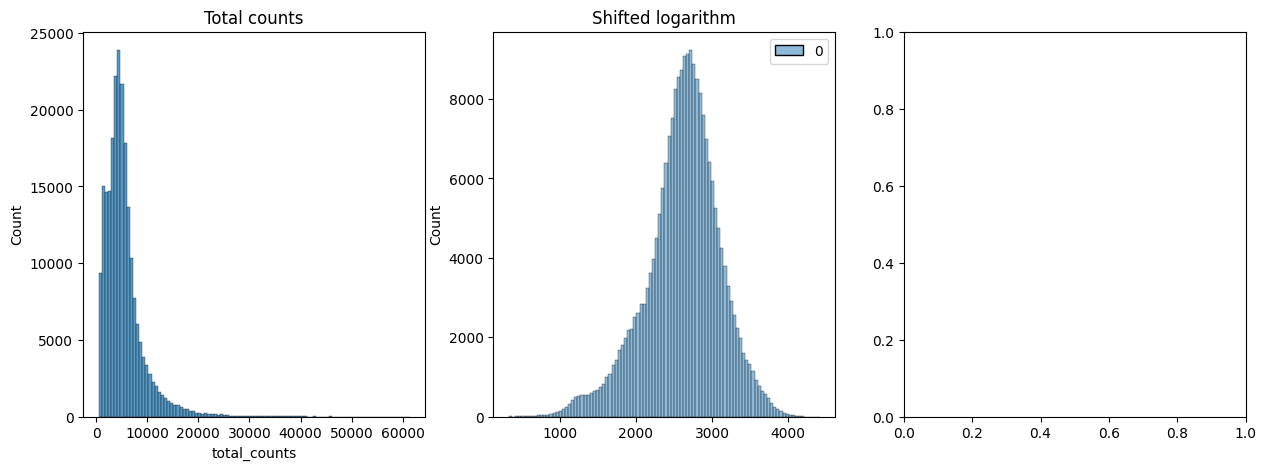

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
#p2 = sns.histplot(adata.layers["log1p_norm_reg"].sum(1), bins=100, kde=False, ax=axes[2])
#axes[2].set_title("Shifted logarithm regressed")
plt.show()

In [24]:
markers = ['Ccl3', 'Xcl1', 'Ccl4', 'Rgs16', 'Ifng', 'Srm', 'Irf8', 'Nr4a1', 'Cd160', 'Tnfrsf9']

#### Gene Scores

In [25]:
activation_genes=['Ccl3', 'Xcl1', 'Ccl4', 'Rgs16', 'Ifng', 'Srm', 'Irf8', 'Nr4a1', 'Cd160', 'Tnfrsf9']
sc.tl.score_genes(adata, activation_genes, score_name='activation_score', use_raw=False)

#treg_genes_1=['Tcf7', 'Bcl2', 'Sell', 'S1pr1', 'Tnfrsf9', 'Relb', 'Ikzf2', 'Pdcd1'] #https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6382439/
treg_genes=['Foxp3', 'Il2ra', 'Il2rb', 'Tnfrsf4', 'Ikzf2', 'Ctla4', 'Gpr83', 'Capg','Izumo1r','Chchd10','Tnfrsf18'] #https://www.immunology.umn.edu/sites/immunology.umn.edu/files/s41590-018-0051-0.pdf
sc.tl.score_genes(adata, treg_genes, score_name='treg_score', use_raw=False)

naive_like_state_genes=['Tcf7','Ccr7','Sell','Lef1','Il7r']
cytotoxic_state_genes=['Klrg1','Prf1','Fcgr4','Cx3cr1']
cytotoxic_activation=['Ccl5', 'Gzmk', 'Gnly', 'Eomes', 'Zfp683','Klrg1', 'Nkg7', 'Zeb2']
cytokine_activation=['Ccl3', 'Ifng', 'Ccl4', 'Xcl1', 'Csf2', 'Il10', 'Hopx', 'Havcr2', 'Lag3', 'Prf1', 'Tnfrsf9', 'Nkg7', 'Il26']

sc.tl.score_genes(adata, naive_like_state_genes, score_name='naive_like_state', use_raw=False)
sc.tl.score_genes(adata, cytotoxic_state_genes, score_name='cytotoxic_state', use_raw=False)
sc.tl.score_genes(adata, cytotoxic_activation, score_name='cytotoxic_activation', use_raw=False)
sc.tl.score_genes(adata, cytokine_activation, score_name='cytokine_activation', use_raw=False)



genes are not in var_names and ignored: Index(['Gnly'], dtype='object')
genes are not in var_names and ignored: Index(['Il26'], dtype='object')


### Compute PCA and UMAP

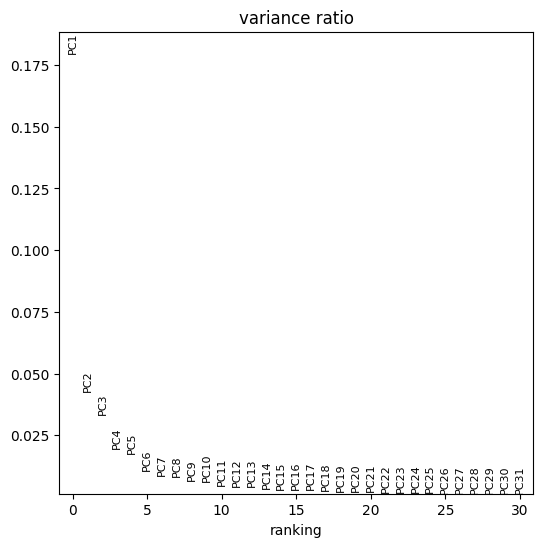

In [26]:
sc.pp.pca(adata, n_comps=50)
n_cells = len(adata)
sc.pl.pca_variance_ratio(adata)

In [27]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=10)

Batch correction

In [28]:
adata.obs.exp_group.unique().tolist()

['mult_neg',
 'mult_pos',
 '1_CD44',
 '2_CD44',
 '3_CD44',
 '1_dp_mult',
 '2_dp_mult',
 '3_dp_mult',
 '4_dp_mult',
 '1_cd107a',
 '2_cd107a',
 '3_cd107a',
 '4_cd107a',
 '5_cd107a',
 '6_cd107a',
 '7_cd107a',
 '8_cd107a']

In [29]:
#Batch balanced kNN method
import bbknn
bbknn.bbknn(adata, batch_key='exp_group', n_pcs=10)

In [30]:
sc.tl.umap(adata)

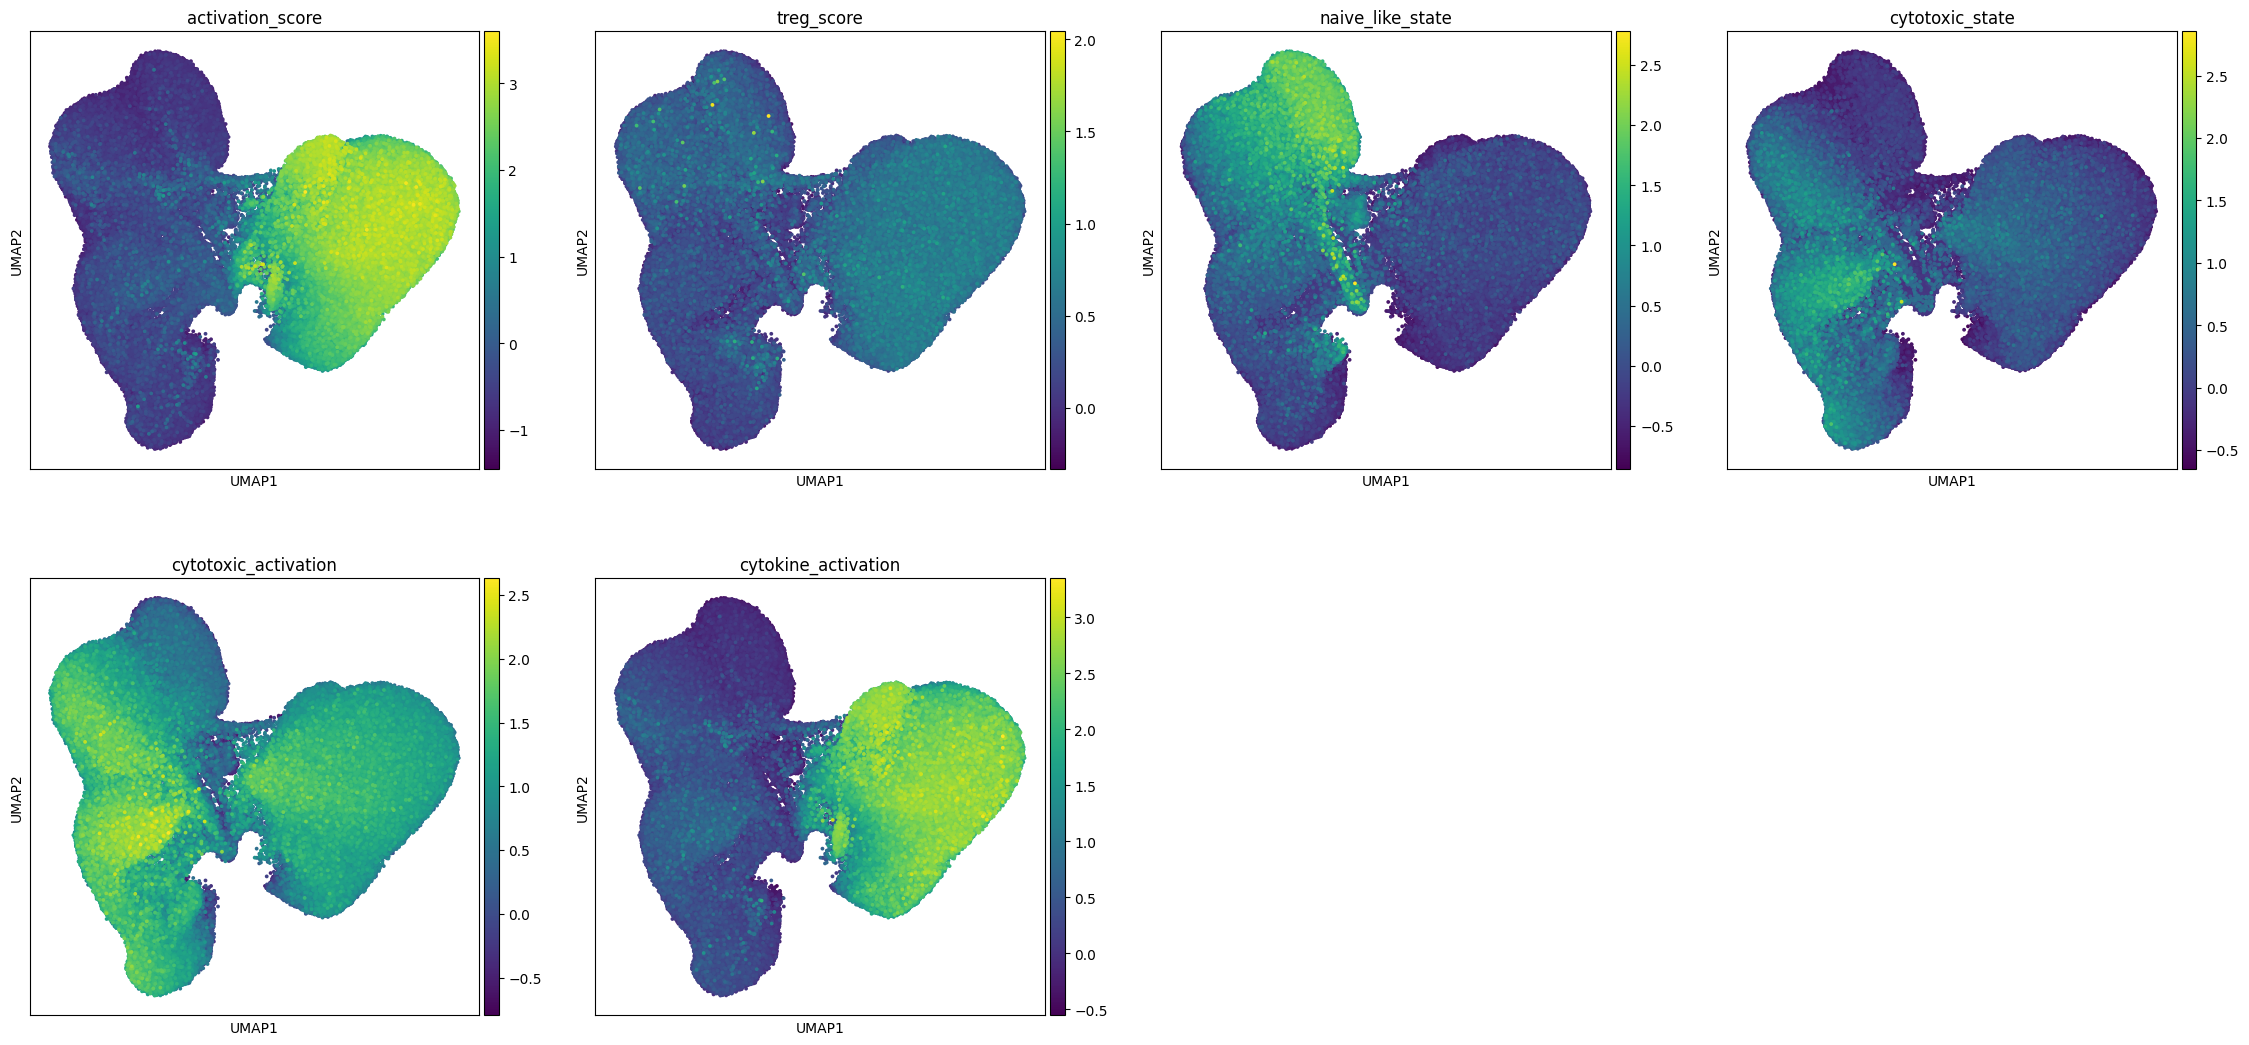

In [31]:
sc.pl.umap(adata, color=['activation_score', 'treg_score','naive_like_state',
                         'cytotoxic_state','cytotoxic_activation','cytokine_activation'],s=30)

### Integrate TCR expression

In [32]:
ir.tl.chain_qc(adata)

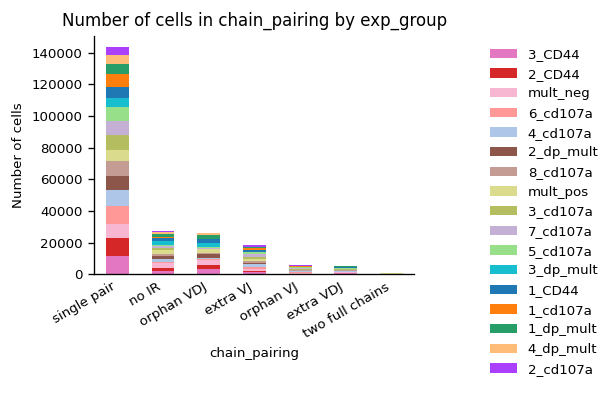

In [33]:
ax=ir.pl.group_abundance(adata, groupby='chain_pairing', target_col='exp_group')

<Axes: title={'center': 'has_ir'}, xlabel='UMAP1', ylabel='UMAP2'>

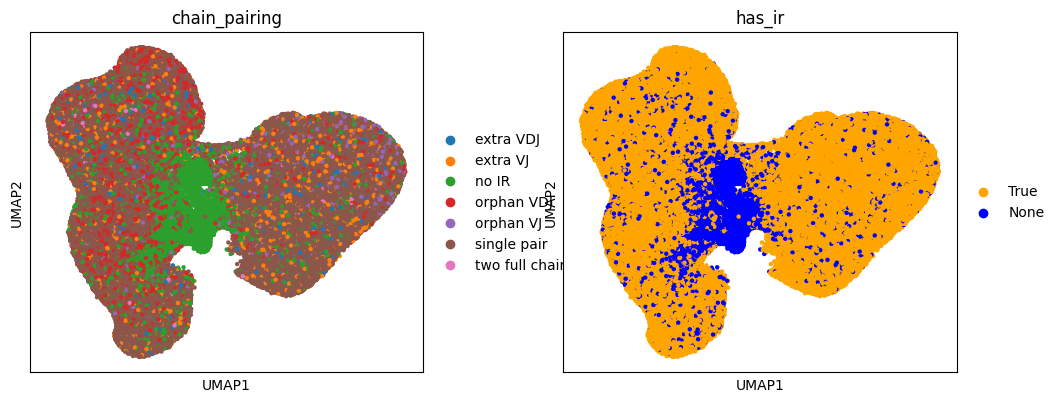

In [34]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
fig.tight_layout(w_pad=7)
sc.pl.umap(adata, color='chain_pairing', ax=ax[0], show=False, s=40)
sc.pl.umap(adata, color='has_ir', palette=['orange', 'blue'], ax=ax[1], show=False, s=40)

#fig.savefig(save_figure_ir + 'UMAP_chain_pairing.eps')

Remove orphan and non-detected TCRs

In [35]:
before_tcr = adata.n_obs

In [36]:
adata = adata[adata.obs["has_ir"] != 'None',:].copy()
adata = adata[~adata.obs["chain_pairing"].isin(["orphan VDJ", "orphan VJ"]), :].copy()

In [37]:
after_tcr = adata.n_obs

In [38]:
print("Cells filtered out due to lack of full TCR expression: " + str(before_tcr-after_tcr))

Cells filtered out due to lack of full TCR expression: 59020


<Axes: title={'center': 'has_ir'}, xlabel='UMAP1', ylabel='UMAP2'>

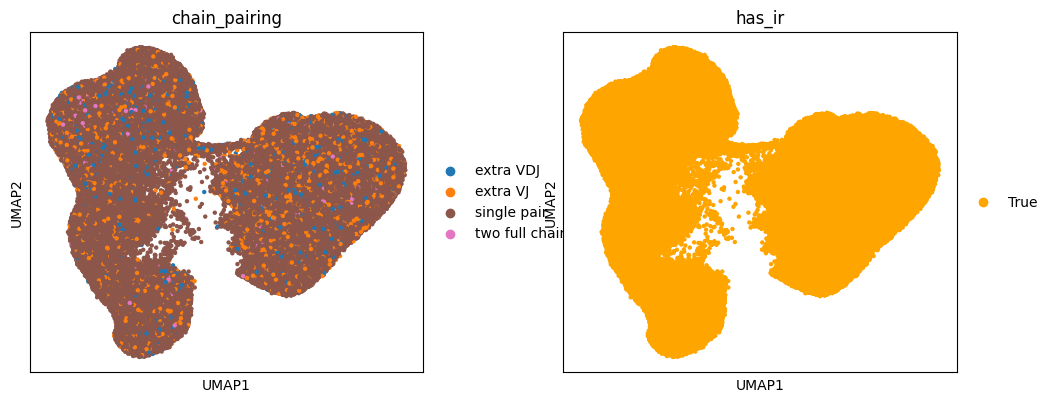

In [39]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
fig.tight_layout(w_pad=7)
sc.pl.umap(adata, color='chain_pairing', ax=ax[0], show=False, s=40)
sc.pl.umap(adata, color='has_ir', palette=['orange', 'blue'], ax=ax[1], show=False, s=40)
#fig.savefig(save_figure_ir + 'UMAP_chain_pairing_After_filter.eps')

### Clustering the neighborhood graph

C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1034179645.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.3)


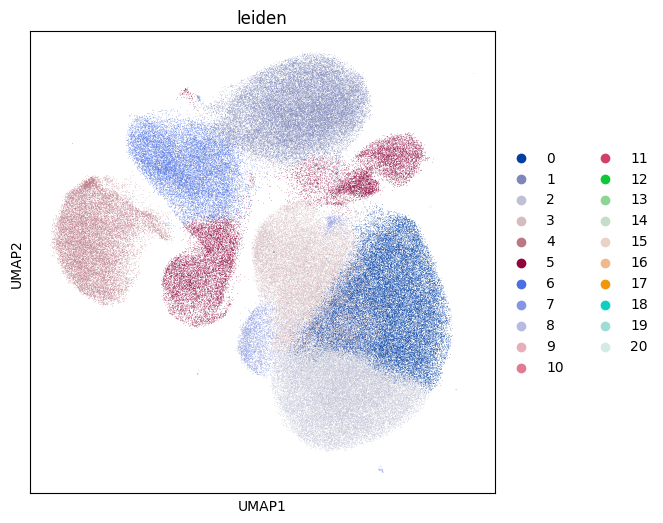

In [40]:
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 0.3)
sc.pl.umap(adata, color='leiden')

define leiden res:

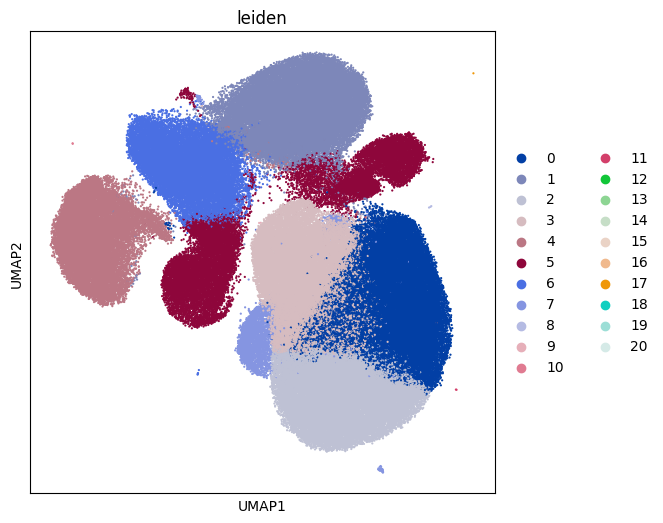

In [41]:
sc.pl.umap(adata, color='leiden', s=10) #save='_leiden_only.pdf

C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\scanpy\plotting\_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


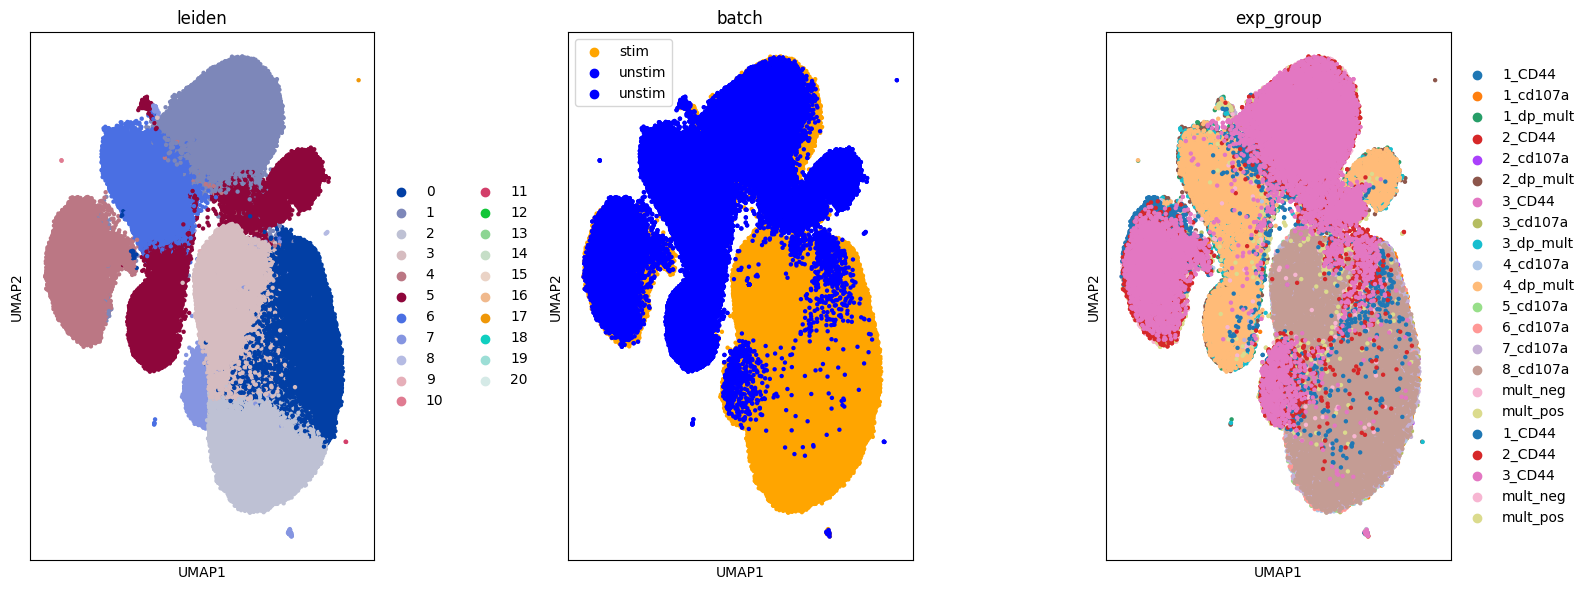

In [42]:
exp_group_list = ['1_CD44','2_CD44','3_CD44','mult_neg','mult_pos']

fig, ax = plt.subplots(ncols=3, figsize=(16,6))

sc.pl.umap(adata, color='leiden', ax=ax[0], show=False, s=40)
sc.pl.umap(adata, color='batch', ax=ax[1], show=False, s=40, palette=['orange', 'blue'])
sc.pl.umap(adata[adata.obs.batch=='unstim'], color='batch', ax=ax[1], show=False, s=40, palette=['blue'], legend_loc=False)
sc.pl.umap(adata, color='exp_group', ax=ax[2], show=False, s=40)
sc.pl.umap(adata[adata.obs.exp_group.isin(exp_group_list)], color='exp_group', ax=ax[2], show=False, s=40)

fig.tight_layout()
#fig.savefig(save_figure_ir + 'UMAP_leiden_batch.eps')

In [43]:
adata.X = adata.layers["log1p_norm"]

In [44]:
adata.layers

Layers with keys: counts, log1p_norm

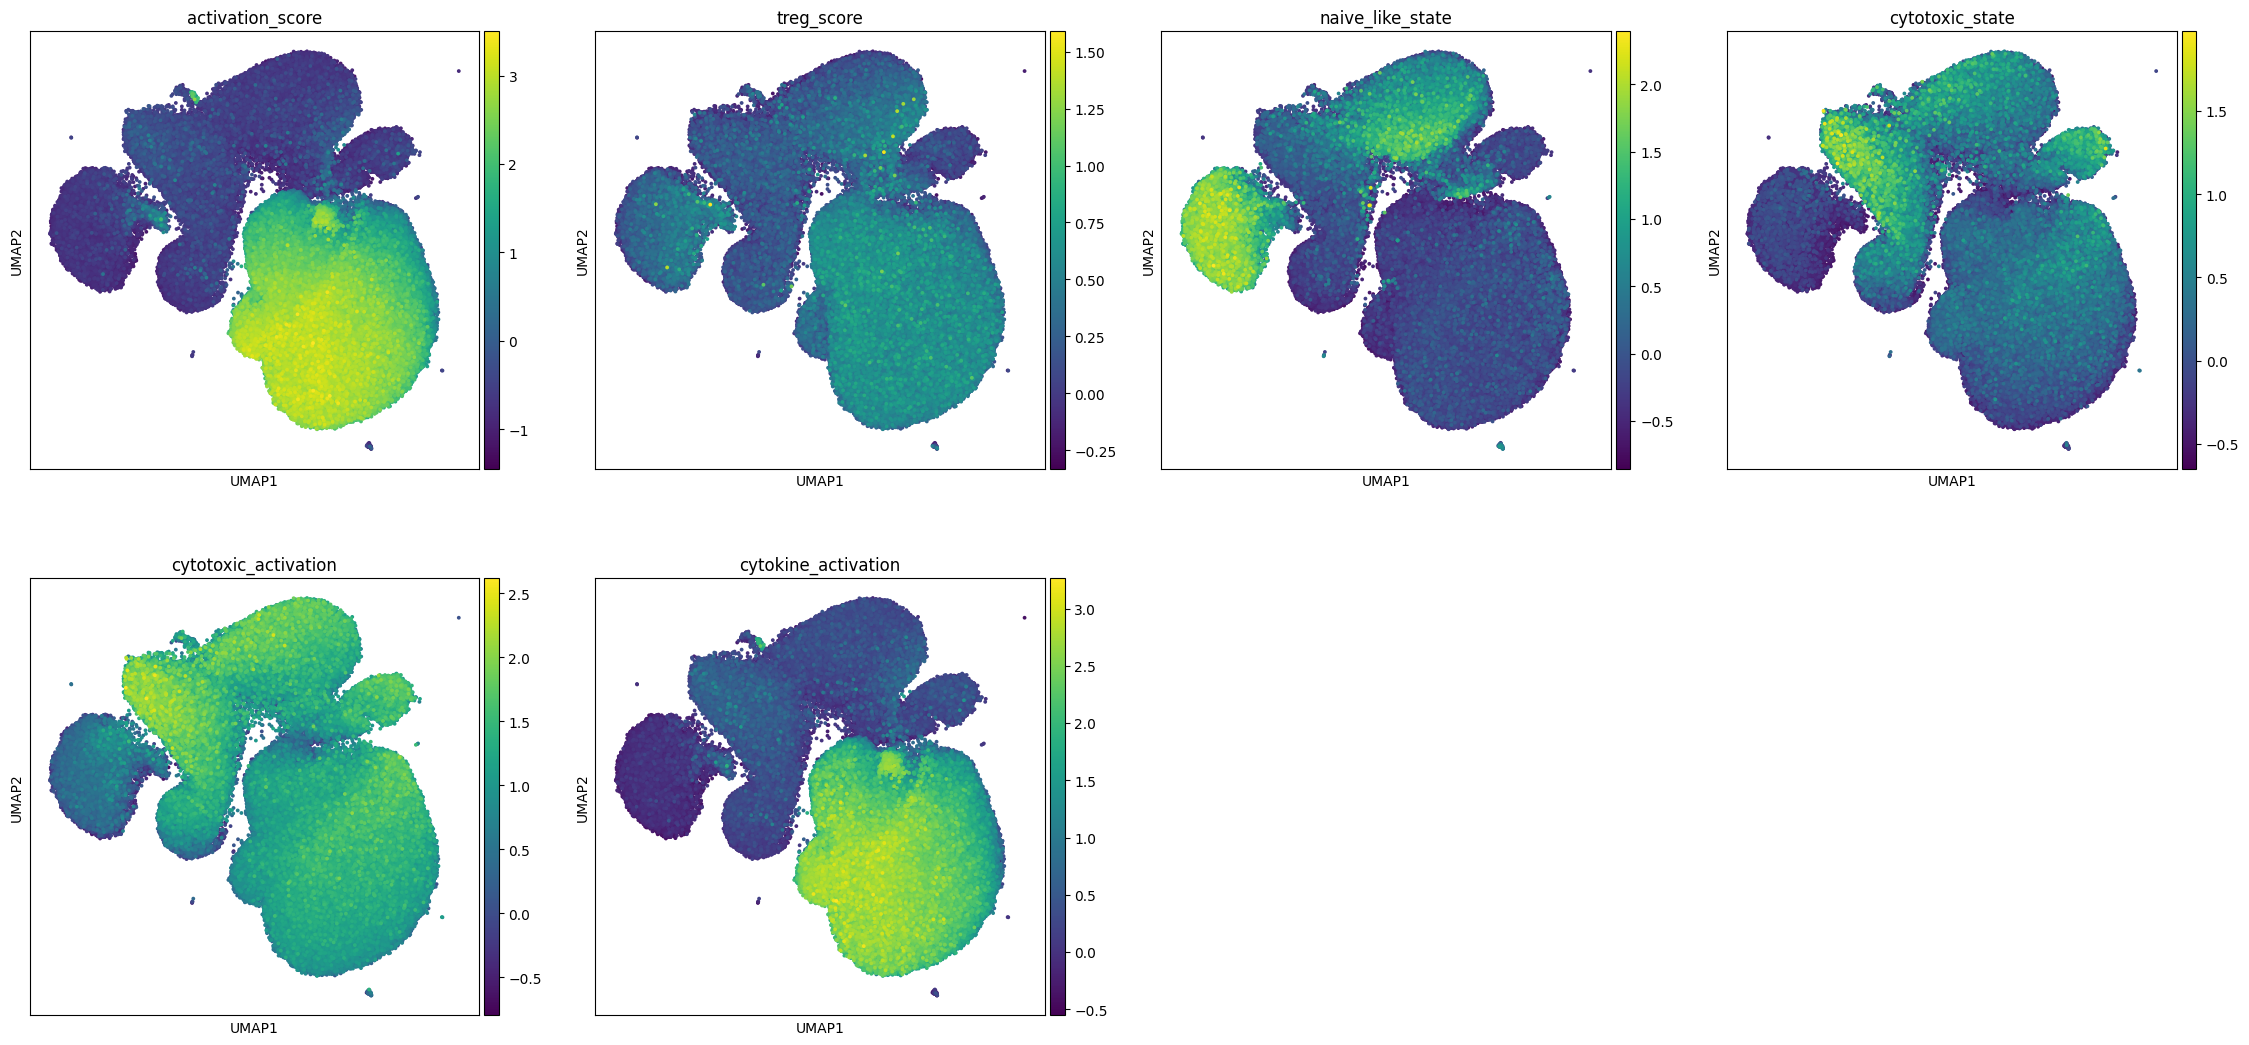

In [45]:
sc.pl.umap(adata, color=['activation_score', 'treg_score','naive_like_state',
                         'cytotoxic_state','cytotoxic_activation','cytokine_activation'],s=30, layer='log1p_norm')
          #save='_gene_scores.pdf')

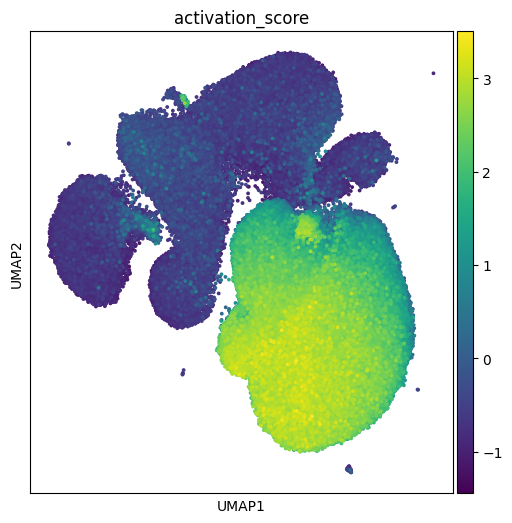

In [46]:
sc.pl.umap(adata, color=['activation_score'],s=30)

In [47]:
#remove single cell outliers for DEG
before = adata.n_obs
df = pd.DataFrame(adata.obs.leiden.value_counts())
leiden_remove = df[df['count']<4].index.tolist()
adata = adata[~adata.obs.leiden.isin(leiden_remove)]
after =  adata.n_obs
print('removed: ' + str(before-after) + 'cells')

removed: 18cells


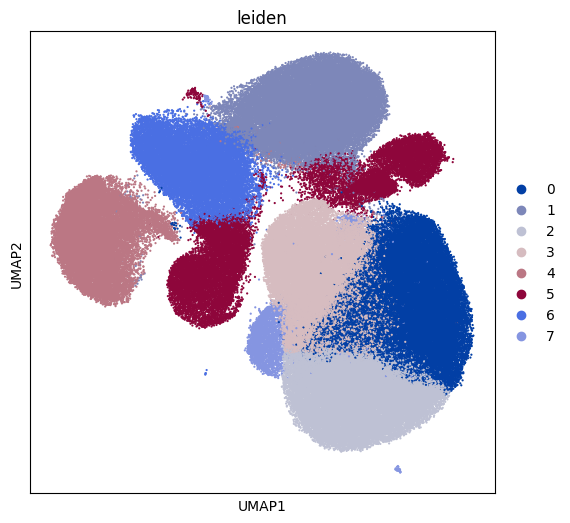

In [48]:
sc.pl.umap(adata, color='leiden', s=10) #save='_leiden_only.pdf'

C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\scanpy\tools\_dendrogram.py:192: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


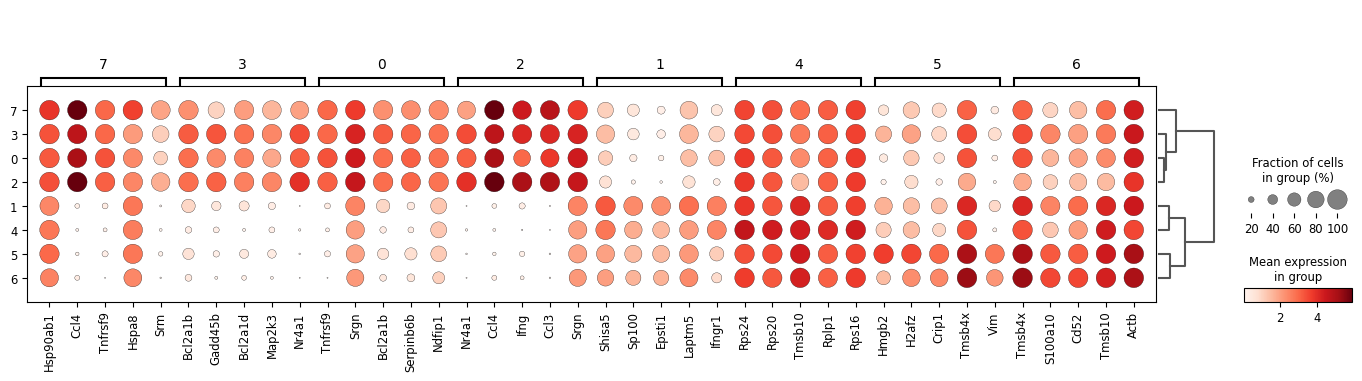

In [49]:
sc.tl.dendrogram(adata, groupby='leiden')
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test', use_raw=False,)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, show=True, use_raw=False) #save='_rank_genes_leiden.eps')

In [50]:
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
results_df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(100)
#results_df.to_excel('./Analysis_output/deg_leiden.xls')

## Clonotype integration

Annotate clono type size by donor

In [51]:
exp_list = adata.obs.experiment.unique().tolist()
exp_group_list = adata.obs.exp_group.unique().tolist()
mouse_list = adata.obs.mouse.unique().tolist()

In [52]:
adata.obs['tra_id'] = adata.obs['IR_VJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VJ_1_junction_aa'].astype(str)
adata.obs['trb_id'] = adata.obs['IR_VDJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_junction_aa'].astype(str)
adata.obs['tcr_id'] = adata.obs['tra_id'] + '__' + adata.obs['trb_id']

adata.obs["TCR_expansion"] = (
    adata.obs
    .groupby(["mouse", "tcr_id"], sort=False, observed=True)["tcr_id"]
    .transform("size")
)

adata.obs['clonotype_size_mouse']=adata.obs['TCR_expansion'].copy()

Annotate meta data

In [53]:
adata.obs['NAME'] = adata.obs.index.copy()
adata.obs['donor_id'] = adata.obs['mouse']
adata.obs['biosample_id'] = adata.obs['experiment']
adata.obs['species'] = 'NCBITaxon_10090'
adata.obs['species__strain'] = 'C57BL/6'
adata.obs['species__ontology_label'] = 'Mus_musculus'
adata.obs['disease'] = 'MONDO_0001449'
adata.obs['disease__strain'] = 'Listeria_monocytogenes_OVA'
adata.obs['disease__ontology_label'] = 'listeriosis'
adata.obs['disease__epitope'] = 'SIINFEKL'
adata.obs['disease__antigen'] = 'OVA'
adata.obs['disease__timepoint'] = 'd8'
adata.obs['organ'] = 'UBERON_0002106'
adata.obs['organ__ontology_label'] = 'spleen'
adata.obs['library_preparation_protocol'] = 'EFO_0009900'
adata.obs['library_preparation_protocol__ontology_label'] = "10x 5' v2"
adata.obs['cell_type'] = "CL_0000625"
adata.obs['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
adata.obs['sex'] = 'female'


Annotation of multimer staining

In [54]:
adata.obs['multimer'] = 'not_stained'
adata.obs.multimer[adata.obs.exp_group=='mult_neg']='ambiguous'
adata.obs.multimer[adata.obs.exp_group=='mult_pos']='ambiguous'
mult_neg_clones = adata.obs.tcr_id[adata.obs.experiment=='mult_neg_us'].unique().tolist()
mult_pos_clones = adata.obs.tcr_id[np.logical_and(adata.obs.experiment=='mult_pos_us', adata.obs.clonotype_size_mouse>1)].unique().tolist()
adata.obs.multimer[adata.obs.tcr_id.isin(mult_neg_clones)]='mult_neg'
adata.obs.multimer[adata.obs.tcr_id.isin(mult_pos_clones)]='mult_pos'
exp_dp_mult = ['1_dp_mult','2_dp_mult','3_dp_mult','4_dp_mult']
for exp in exp_dp_mult:
    adata.obs.multimer[adata.obs.exp_group==exp]='ambiguous'
    mult_pos_clones = adata.obs.tcr_id[np.logical_and(
        adata.obs.experiment==exp, adata.obs.clonotype_size_mouse>1)].unique().tolist()
    adata.obs.multimer[adata.obs.tcr_id.isin(mult_pos_clones)]='mult_pos'

C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\146951342.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs.multimer[adata.obs.exp_group=='mult_neg']='ambiguous'
C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\146951342.py:

Annotation of reactivity score

C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1610845748.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=list(range(1, len(activation_score_list[i])+1)), y=activation_score_list[i], palette=['royalblue'], ax=ax[axis,index])
C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1610845748.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=list(range(1, len(activation_score_list[i])+1)), y=activation_score_list[i], palette=['royalblue'], ax=ax[axis,index])
C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1610845748.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=list(range(1, len(activation_score_list[i])+1)), y=activation_score_list[i], palette=['royalblue'], ax=ax[axis,index])
C:\Users\Adrian\AppData\Local\Temp\ipykernel_18396\1610845748.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.li

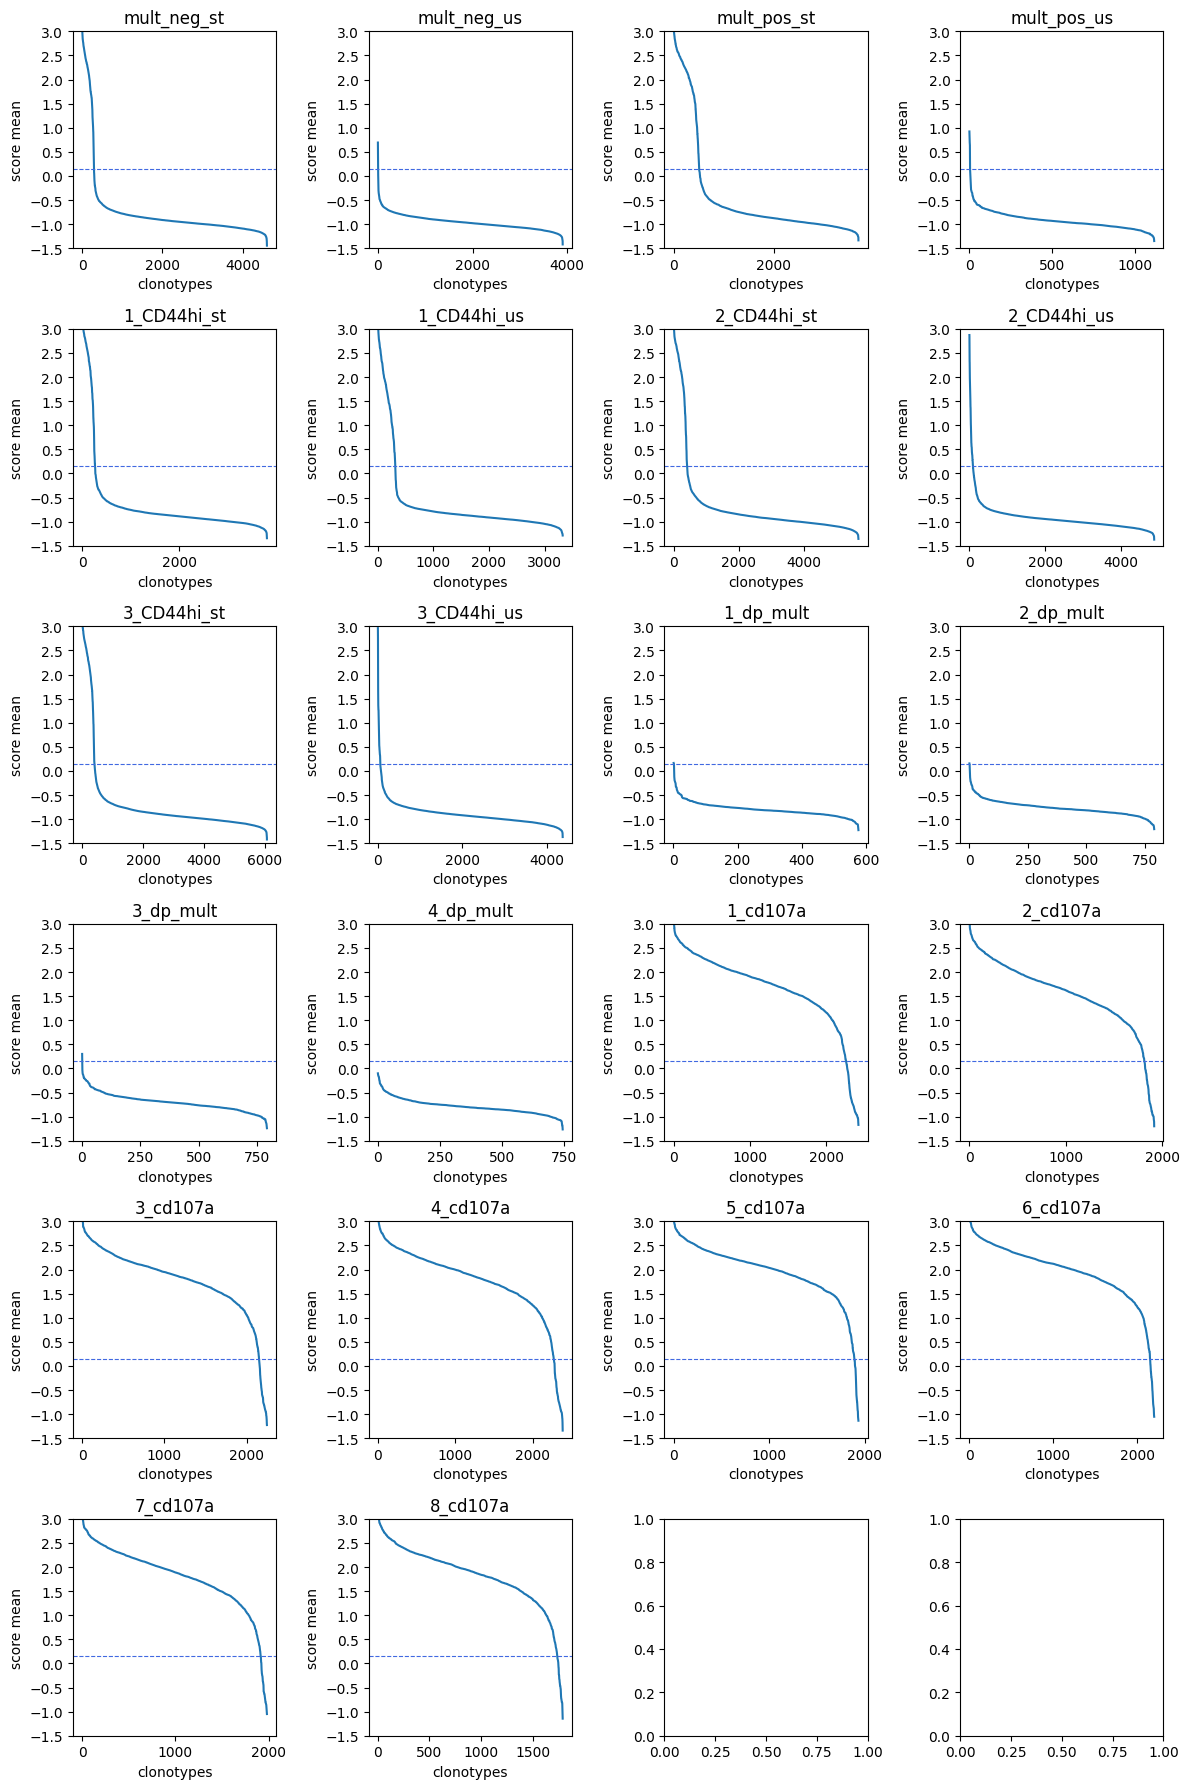

In [55]:
exp_list = adata.obs.experiment.unique().tolist()
activation_score_list = []
for i, exp in enumerate(exp_list):
    score = adata.obs[adata.obs.experiment==exp].groupby('tcr_id').agg({
    'activation_score':'mean'
    }).dropna().activation_score.tolist()
    activation_score_list.append(score)
    activation_score_list[i].sort(reverse=True)
ncols = 4
nrows = (len(exp_list)//ncols)+1

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,18))
index = 0
axis = 0
y_pos=[-1.5,-1,-0.5,0,0.5,1,1.5,2.0,2.5,3.0]

#styles=['royalblue', 'silver']
#lws = [3, 1.5]

for i, exp in enumerate(exp_list):
    sns.lineplot(x=list(range(1, len(activation_score_list[i])+1)), y=activation_score_list[i], palette=['royalblue'], ax=ax[axis,index])
    ax[axis,index].axhline(0.15, color='royalblue', linewidth=0.8, linestyle = 'dashed')
    ax[axis,index].set_ylim([-1,1.5])
    ax[axis,index].set_yticks(y_pos)
    ax[axis,index].set_xlabel('clonotypes')
    ax[axis,index].set_ylabel('score mean')
    ax[axis,index].set_title(exp)
    
    if index <ncols-1:
        index = index + 1
    else:
        axis = axis+1
        index=0

fig.tight_layout()
plt.show()

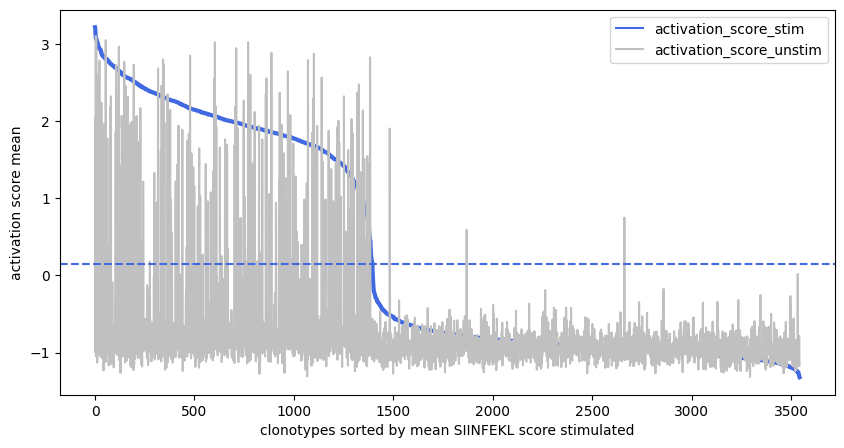

In [56]:
dp_mult_list = ['1_dp_mult',
 '2_dp_mult',
 '3_dp_mult',
 '4_dp_mult',]
cd107a_list = ['1_cd107a',
 '2_cd107a',
 '3_cd107a',
 '4_cd107a',
 '5_cd107a',
 '6_cd107a',
 '7_cd107a',
 '8_cd107a']
 
clones_dp_mult = adata.obs.tcr_id[adata.obs.experiment.isin(dp_mult_list)].unique().tolist()
clones_cd107a = adata.obs.tcr_id[adata.obs.experiment.isin(cd107a_list)].unique().tolist()
clones_stim_unstim = [x for x in clones_dp_mult if x in clones_cd107a]

#plot activation score
df_SIINFEKL_stim = adata.obs[adata.obs.batch=='stim'].groupby('tcr_id').agg({
    'activation_score':'mean'
})

df_SIINFEKL_stim.index.name='tcr_id'
df_SIINFEKL_stim=df_SIINFEKL_stim.add_suffix('_stim')  #rename column names
df_SIINFEKL_stim=df_SIINFEKL_stim.dropna()


df_SIINFEKL_unstim = adata.obs[adata.obs.batch=='unstim'].groupby('tcr_id').agg({
    'activation_score':'mean'
})

df_SIINFEKL_unstim.index.name='tcr_id'
df_SIINFEKL_unstim=df_SIINFEKL_unstim.add_suffix('_unstim')  #rename column names
df_SIINFEKL_unstim=df_SIINFEKL_unstim.dropna()
#Merge Dataframes
df_SIINFEKL = pd.merge(df_SIINFEKL_stim, df_SIINFEKL_unstim, on='tcr_id')
#plot data
styles=['royalblue', 'silver']
lws = [3, 1.5]

fig, ax = plt.subplots(figsize=(10,5))

ax = df_SIINFEKL.sort_values('activation_score_stim', ascending=False).reset_index(drop=True).plot(style=styles, ax=ax)
for i, l in enumerate(ax.lines):
    plt.setp(l, linewidth=lws[i])
plt.axhline(y = 0.15, color = 'royalblue', linestyle = 'dashed')
ax.set_xlabel('clonotypes sorted by mean SIINFEKL score stimulated')
ax.set_ylabel('activation score mean')
ax.set_xticks(np.arange(0,len(df_SIINFEKL), 500))

plt.show()

Get score across all to define threshold

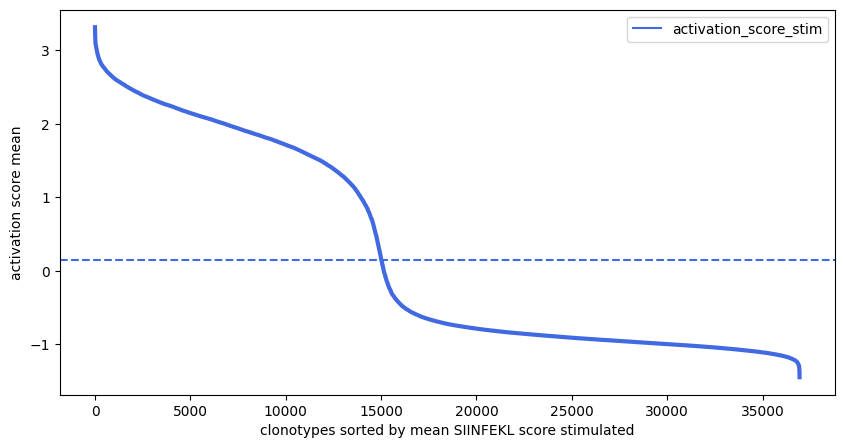

In [57]:
df_SIINFEKL = adata.obs[adata.obs.batch=='stim'].groupby('tcr_id').agg({
    'activation_score':'mean'
})

df_SIINFEKL.index.name='tcr_id'
df_SIINFEKL=df_SIINFEKL.add_suffix('_stim')  #rename column names
df_SIINFEKL=df_SIINFEKL.dropna()
styles=['royalblue', 'silver']
lws = [3, 1.5]

fig, ax = plt.subplots(figsize=(10,5))


ax = df_SIINFEKL.sort_values('activation_score_stim', ascending=False).reset_index(drop=True).plot(style=styles, ax=ax)
for i, l in enumerate(ax.lines):
    plt.setp(l, linewidth=lws[i])
plt.axhline(y = 0.15, color = 'royalblue', linestyle = 'dashed')
ax.set_xlabel('clonotypes sorted by mean SIINFEKL score stimulated')
ax.set_ylabel('activation score mean')

plt.show()

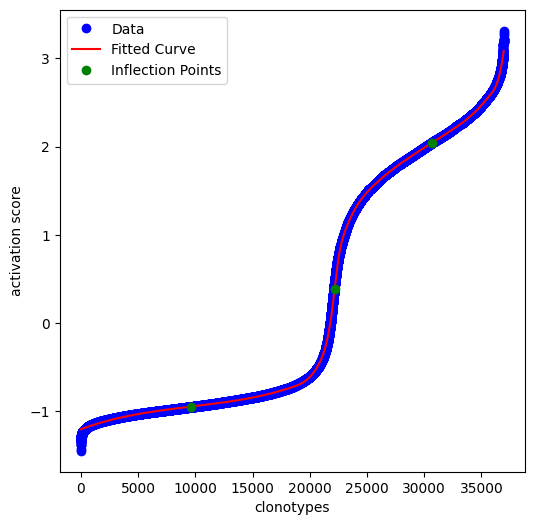

[ 9620.31886377 22166.63332667 30656.45389078]
activation score threshold: 0.44870605468750013
0.44870605468750013


In [58]:
df = df_SIINFEKL.sort_values('activation_score_stim', ascending=True).reset_index(drop=True)
df.index

from scipy.interpolate import UnivariateSpline

# Sort the data based on x-values (if needed)
y_data = df.activation_score_stim
x_data = df.index
# Generate a range of x-values for plotting
x_range = np.linspace(min(x_data), max(x_data), 5000)

# Fit the curve using smoothing splines
spline = UnivariateSpline(x_data, y_data, s=5)

# Evaluate the fitted function at a specific x-value
x = 20000
y_fit = spline(x)
# Compute the first derivative of the spline function
spline_derivative = spline.derivative()
# Compute the second derivative of the spline function
spline_second_derivative = spline_derivative.derivative()
# Find the x-values where the sign of the second derivative changes
inflection_points = x_range[np.where(np.diff(np.sign(spline_second_derivative(x_range))))[0]]

# Plot the data and the fitted curve
plt.plot(x_data, y_data, 'bo', label='Data')
plt.plot(x_range, spline(x_range), 'r-', label='Fitted Curve')

# Plot the inflection points
plt.plot(inflection_points, spline(inflection_points), 'go', label='Inflection Points')

# Add labels and legend
plt.xlabel('clonotypes')
plt.ylabel('activation score')
plt.legend()

plt.show()

print(inflection_points)
print("activation score threshold: " + str(y_data[int(inflection_points[1]+1)]))

act_score_threshold = y_data[int(inflection_points[1]+1)]
print(act_score_threshold)

Annotate reactivity

In [59]:
adata.obs.exp_group.unique().tolist()

['mult_neg',
 'mult_pos',
 '1_CD44',
 '2_CD44',
 '3_CD44',
 '1_dp_mult',
 '2_dp_mult',
 '3_dp_mult',
 '4_dp_mult',
 '1_cd107a',
 '2_cd107a',
 '3_cd107a',
 '4_cd107a',
 '5_cd107a',
 '6_cd107a',
 '7_cd107a',
 '8_cd107a']

mean activation score per tcr - activation score in stim is first annotation

In [60]:
# mean across all cells per TCR
mean_all = (
    adata.obs
    .groupby("tcr_id", observed=True)["activation_score"]
    .mean()
)

# mean across stimulated cells only
mean_stim = (
    adata.obs.loc[adata.obs["batch"] == "stim"]
    .groupby("tcr_id", observed=True)["activation_score"]
    .mean()
)

# default = mean across all cells
mean_tcr = mean_all.copy()

# wherever a TCR occurs in stim, replace with stim-only mean
mean_tcr.loc[mean_stim.index] = mean_stim

# annotate every occurrence of that tcr_id
adata.obs["mean_tcr_activation_score"] = (
    adata.obs["tcr_id"].map(mean_tcr)
)

In [61]:
adata.obs["isolated_specificity"] = 'OVA'
adata.obs["sequencing_specificity"] = "below_threshold"

Annotate reactivity

In [62]:
mult_exp = ['1_dp_mult','2_dp_mult','3_dp_mult','4_dp_mult']
stim_exp = ['mult_pos','mult_neg','1_CD44','2_CD44','3_CD44','1_cd107a','2_cd107a',
            '3_cd107a','4_cd107a','5_cd107a','6_cd107a','7_cd107a','8_cd107a']
adata.obs["sequencing_specificity_test2"] = "below_threshold"

In [63]:
threshold = 2
subset_values = mult_exp

assigned_specificity = "OVA"

# rows that qualify
mask = (
    adata.obs["exp_group"].isin(subset_values)
    & (adata.obs["TCR_expansion"] >= threshold)
)

# tcr_ids that qualify at least once
qualifying_tcrs = adata.obs.loc[mask, "tcr_id"].unique()

# assign to ALL occurrences of those tcr_ids
adata.obs.loc[
    adata.obs["tcr_id"].isin(qualifying_tcrs),
    "sequencing_specificity"
] = assigned_specificity

In [64]:
threshold = 2
subset_values = stim_exp

assigned_specificity = "OVA"

# rows that qualify
mask = (
    adata.obs["exp_group"].isin(subset_values)
    & (adata.obs["TCR_expansion"] >= threshold)
    & (adata.obs["mean_tcr_activation_score"] > act_score_threshold)
)

# tcr_ids that qualify at least once
qualifying_tcrs = adata.obs.loc[mask, "tcr_id"].unique()

# assign to ALL occurrences of those tcr_ids
adata.obs.loc[
    adata.obs["tcr_id"].isin(qualifying_tcrs),
    "sequencing_specificity"
] = assigned_specificity

In [65]:
adata_file = 'processed_adata_OVA.h5ad'
adata.write(adata_directory+adata_file)

In [66]:
df_obs = pd.DataFrame(adata.obs)#.to_csv('./obs_df_OVA.csv', index=False)
for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")

In [67]:
from preprocess_tcr_2 import preprocess_tcr_vj_vdj
df = preprocess_tcr_vj_vdj(df_obs)
df.to_csv('./obs_df_OVA.csv', index=False)

Update reactivity annotation

In [1]:
import matplotlib_inline.backend_inline as backend_inline
import IPython.display as disp
# Make set_matplotlib_formats available where Scanpy expects it
disp.set_matplotlib_formats = backend_inline.set_matplotlib_formats

import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
#import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

C:\Users\wwspa\miniconda3\envs\tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import glob
import os
from pathlib import Path

sample_directory = './GEX_VDJ/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

In [3]:
adata_file = 'processed_adata_OVA.h5ad'
adata = sc.read(adata_directory+adata_file)

In [4]:
adata.obs['mouse'] = adata.obs['mouse'].astype('string') + '_' +  adata.obs['isolated_specificity'].astype('string')
adata.obs['donor_id'] = adata.obs['mouse']


In [5]:
adata.obs['biosample_id'] = adata.obs['experiment']
adata.obs['species'] = 'NCBITaxon_10090'
adata.obs['species__strain'] = 'C57BL/6'
adata.obs['species__ontology_label'] = 'Mus musculus'
adata.obs['disease'] = 'MONDO_0005828'
adata.obs['disease__strain'] = 'Listeria_monocytogenes_OVA'
adata.obs['disease__ontology_label'] = 'listeriosis'
adata.obs['disease__epitope'] = 'SIINFEKL'
adata.obs['disease__antigen'] = 'OVA'
adata.obs['disease__timepoint'] = 'd8'
adata.obs['organ'] = 'UBERON_0002106'
adata.obs['organ__ontology_label'] = 'spleen'
adata.obs['library_preparation_protocol'] = 'EFO_0009900'
adata.obs['library_preparation_protocol__ontology_label'] = "10x 5' v2"
adata.obs['cell_type'] = "CL_0000625"
adata.obs['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
adata.obs['sex'] = 'female'


In [6]:
mult_exp = ['1_dp_mult','2_dp_mult','3_dp_mult','4_dp_mult','mult_pos']
stim_exp = ['mult_neg','1_CD44','2_CD44','3_CD44','1_cd107a','2_cd107a',
            '3_cd107a','4_cd107a','5_cd107a','6_cd107a','7_cd107a','8_cd107a']
adata.obs["sequencing_specificity"] = "below_threshold"

In [7]:
threshold = 2
subset_values = mult_exp

assigned_specificity = "OVA"

# rows that qualify
mask = (
    adata.obs["exp_group"].isin(subset_values)
    & (adata.obs["TCR_expansion"] >= threshold)
)

# tcr_ids that qualify at least once
qualifying_tcrs = adata.obs.loc[mask, "tcr_id"].unique()

# assign to ALL occurrences of those tcr_ids
adata.obs.loc[
    adata.obs["tcr_id"].isin(qualifying_tcrs),
    "sequencing_specificity"
] = assigned_specificity

In [8]:
act_score_threshold = 0.44870605468750013

In [9]:
threshold = 2
subset_values = stim_exp

assigned_specificity = "OVA"

# rows that qualify
mask = (
    adata.obs["exp_group"].isin(subset_values)
    & (adata.obs["TCR_expansion"] >= threshold)
    & (adata.obs["mean_tcr_activation_score"] > act_score_threshold)
)

# tcr_ids that qualify at least once
qualifying_tcrs = adata.obs.loc[mask, "tcr_id"].unique()

# assign to ALL occurrences of those tcr_ids
adata.obs.loc[
    adata.obs["tcr_id"].isin(qualifying_tcrs),
    "sequencing_specificity"
] = assigned_specificity

In [10]:
df_obs = pd.DataFrame(adata.obs)#.to_csv('./obs_df_OVA.csv', index=False)
for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")

In [11]:
from preprocess_tcr_2 import preprocess_tcr_vj_vdj
df = preprocess_tcr_vj_vdj(df_obs)
df.to_csv('./obs_df_OVA.csv', index=False)

In [12]:
adata_file = 'processed_adata_OVA.h5ad'
adata.write(adata_directory+adata_file)